# Data Preparation

In [0]:
import pandas as pd

# Import our synthetic dataset from GitHub repo
raw_url = "https://raw.githubusercontent.com/jazz1416/VetTrack-Customer-Service-Agent/refs/heads/main/synthetic_customer_support_tickets.csv"

df = pd.read_csv(raw_url)

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Minutes to resolve
0,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,7/14/20,Client Communication (Email/SMS),SMS Reminders Not Sending,We've noticed that SMS reminders for upcoming ...,Closed,We conducted a thorough investigation and foun...,Critical,Social media,6/1/23 11:14,6/1/23 18:05,3.0,120.0
1,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,11/13/20,Client Communication (Email/SMS),SMS Reminders Not Sending,Clients have reported that they are not receiv...,Closed,"After analyzing the system logs, we discovered...",Critical,Social media,6/1/23 7:29,6/1/23 1:57,3.0,90.0
2,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2/4/20,Client Communication (Email/SMS),SMS Reminders Not Sending,The SMS reminders for pet vaccinations are fai...,Closed,The issue was traced back to a software update...,Critical,Email,6/1/23 0:12,6/1/23 19:53,1.0,150.0
3,11,Joseph Moreno,mbrown@example.org,48,Male,Nintendo Switch,1/19/21,Client Communication (Email/SMS),SMS Reminders Not Sending,We're experiencing an issue where no SMS remin...,Closed,"Upon review, we found a server-side script fai...",Critical,Phone,6/1/23 17:46,5/31/23 23:51,1.0,110.0
4,12,Brandon Arnold,davisjohn@example.net,51,Male,Microsoft Xbox Controller,10/24/21,Client Communication (Email/SMS),SMS Reminders Not Sending,All SMS reminders for our upcoming appointment...,Closed,The SMS queue was overloaded due to a bug in t...,Critical,Chat,6/1/23 12:05,6/1/23 9:27,1.0,130.0


### Dataset Overview

In [0]:
# Print number of rows and columns in dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8469
Columns: 18


In [0]:
# Display column types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [0]:
# Summary stats
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating,Minutes to resolve
count,8469.000000,8469.000000,2769.000000,2769.000000
mean,4235.000000,44.026804,2.991333,59.970386
std,2444.934048,15.296112,1.407016,59.790408
min,1.000000,18.000000,1.000000,5.000000
25%,2118.000000,31.000000,2.000000,12.000000
50%,4235.000000,44.000000,3.000000,30.000000
75%,6352.000000,57.000000,4.000000,110.000000
max,8469.000000,70.000000,5.000000,480.000000


###  Preprocessing

In [0]:
# Get columns that contain n/a values
df.columns[df.isna().any()].tolist()

['Resolution',
 'First Response Time',
 'Time to Resolution',
 'Customer Satisfaction Rating',
 'Minutes to resolve']

In [0]:
# Fill na values that can easily be filled
df['Resolution'] = df['Resolution'].fillna("No resolution provided")
# Fill empty customer satisfaction ratings with the median value 
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].fillna(3)
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Minutes to resolve
0,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,7/14/20,Client Communication (Email/SMS),SMS Reminders Not Sending,We've noticed that SMS reminders for upcoming ...,Closed,We conducted a thorough investigation and foun...,Critical,Social media,6/1/23 11:14,6/1/23 18:05,3.0,120.0
1,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,11/13/20,Client Communication (Email/SMS),SMS Reminders Not Sending,Clients have reported that they are not receiv...,Closed,"After analyzing the system logs, we discovered...",Critical,Social media,6/1/23 7:29,6/1/23 1:57,3.0,90.0
2,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2/4/20,Client Communication (Email/SMS),SMS Reminders Not Sending,The SMS reminders for pet vaccinations are fai...,Closed,The issue was traced back to a software update...,Critical,Email,6/1/23 0:12,6/1/23 19:53,1.0,150.0
3,11,Joseph Moreno,mbrown@example.org,48,Male,Nintendo Switch,1/19/21,Client Communication (Email/SMS),SMS Reminders Not Sending,We're experiencing an issue where no SMS remin...,Closed,"Upon review, we found a server-side script fai...",Critical,Phone,6/1/23 17:46,5/31/23 23:51,1.0,110.0
4,12,Brandon Arnold,davisjohn@example.net,51,Male,Microsoft Xbox Controller,10/24/21,Client Communication (Email/SMS),SMS Reminders Not Sending,All SMS reminders for our upcoming appointment...,Closed,The SMS queue was overloaded due to a bug in t...,Critical,Chat,6/1/23 12:05,6/1/23 9:27,1.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8448,Devin Parsons,jonathanfox@example.org,51,Other,GoPro Hero,7/12/20,Refund request,Installation support,There seems to be a hardware problem with my {...,Pending Customer Response,No resolution provided,Critical,Email,6/1/23 18:00,NaN,3.0,NaN
8465,8450,Kyle Roy,maldonadosharon@example.org,28,Other,Dyson Vacuum Cleaner,11/22/20,Refund request,Display issue,I'm having an issue with the {product_purchase...,Pending Customer Response,No resolution provided,High,Social media,6/1/23 19:11,NaN,3.0,NaN
8466,8455,Jill Leon,murrayanna@example.org,51,Female,Samsung Galaxy,3/11/20,Cancellation request,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,No resolution provided,Low,Email,6/1/23 12:24,NaN,3.0,NaN
8467,8459,Adam Nunez,gregory69@example.net,47,Other,Amazon Echo,7/28/20,Billing inquiry,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,No resolution provided,Medium,Chat,6/1/23 17:26,NaN,3.0,NaN


In [0]:
import pandas as pd

# Cast columns to proper data types
df['Ticket ID'] = df['Ticket ID'].astype('int64')
df['Customer Name'] = df['Customer Name'].astype('string')
df['Customer Email'] = df['Customer Email'].astype('string')
df['Customer Age'] = df['Customer Age'].astype('int64')
df['Customer Gender'] = df['Customer Gender'].astype('string')
df['Product Purchased'] = df['Product Purchased'].astype('string')
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['Ticket Type'] = df['Ticket Type'].astype('string')
df['Ticket Subject'] = df['Ticket Subject'].astype('string')
df['Ticket Description'] = df['Ticket Description'].astype('string')
df['Ticket Status'] = df['Ticket Status'].astype('string')
df['Resolution'] = df['Resolution'].astype('string')
df['Ticket Priority'] = df['Ticket Priority'].astype('string')
df['Ticket Channel'] = df['Ticket Channel'].astype('string')
df['First Response Time'] = pd.to_datetime(df['First Response Time'])
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'])
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].astype('int64')
df['Minutes to resolve'] = df['Minutes to resolve'].astype('Int64')

In [0]:
# Ensure that columns are the right data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   string        
 2   Customer Email                8469 non-null   string        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   string        
 5   Product Purchased             8469 non-null   string        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   string        
 8   Ticket Subject                8469 non-null   string        
 9   Ticket Description            8469 non-null   string        
 10  Ticket Status                 8469 non-null   string        
 11  Resolution                    

In [0]:
import re

# Normalize text
def normalize_text(text):
    """
    Standardizes text for the agent to read better
    """
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# Normalize text for necessary columns
df['Ticket Description'] = df['Ticket Description'].apply(normalize_text)
df['Resolution'] = df['Resolution'].apply(normalize_text)

In [0]:
cat_cols = ['Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Ticket Status', 'Ticket Priority', 'Ticket Channel']

# Create a new column with int values for each category 
for col in cat_cols:
    numerical_values, _ = pd.factorize(df[col])
    current_index = df.columns.get_loc(col)
    new_col_name = f'{col} ID'
    df.insert(current_index + 1, column = new_col_name, value = numerical_values)

In [0]:
import numpy as np

# Create new column that indicates if a ticket has yet to be picked up 
# due to a lack of information
df['Awaiting Additional Information'] = np.where(df['First Response Time'].isna(), 'yes', 'no')

In [0]:
pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.4/426.4 MB 142.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.6/444.6 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.1/221.1 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.5/188.5 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [0]:
# Create embeddings with batch processing
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

# Store ticket descriptions in list for embeddings
texts = df['Ticket Description'].tolist()

# Process embeddings in batches
batch_size = 1000
embeddings = model.encode(texts, batch_size=batch_size, show_progress_bar=True)

# Create new column in df to store embeddings
df['embeddings'] = list(embeddings)
print(f"Created embeddings with shape: {embeddings.shape}")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-994fa4f1-cdbb-4743-8bcc-a951f3308436/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Created embeddings with shape: (8469, 384)


In [0]:
# Create the default catalog and schema if they don't already exist
spark.sql("CREATE CATALOG IF NOT EXISTS main")
spark.sql("CREATE SCHEMA IF NOT EXISTS main.default")

DataFrame[]

In [0]:
# Unity Catalog location: catalog.schema.table
catalog = "main"
schema = "default"
table_name = "final_project"

# Rename columns to replace spaces with underscores 
df.columns = df.columns.str.replace(' ', '_')

# Convert Pandas DataFrame to Spark and write as Delta
# mode("overwrite") replaces the table if it exists (good for re-running the lab)
final_project = spark.createDataFrame(df)
final_project.write.format("delta").mode("overwrite").saveAsTable(f"{catalog}.{schema}.{table_name}")

# Verify: query the table
display(spark.table(f"{catalog}.{schema}.{table_name}").limit(5))

Ticket_ID Customer_Name Customer_Email Customer_Age Customer_Gender Customer_Gender_ID Product_Purchased Product_Purchased_ID Date_of_Purchase Ticket_Type Ticket_Type_ID Ticket_Subject Ticket_Subject_ID Ticket_Description Ticket_Status Ticket_Status_ID Resolution Ticket_Priority Ticket_Priority_ID Ticket_Channel Ticket_Channel_ID First_Response_Time Time_to_Resolution Customer_Satisfaction_Rating Minutes_to_resolve Awaiting_Additional_Information embeddings 5323 Christine Mcguire baileypeter@example.com 37 Female 1 Sony Xperia 22 2021-10-05T00:00:00.000Z Technical issue 11 Refund request 25 im unable to access my productpurchased account it keeps displaying an invalid credentials error even though im using the correct login information how can i regain access to my account if you im concerned about the security of my productpurchased and would like to ensure that my data is safe Pending Customer Response 2 no resolution provided Medium 1 Chat 3 2023-06-01T16:30:00.000Z null 3 null no List(0.003282017, 0.0021492615, -0.043531924, -0.11755647, -0.05695664, 0.06496067, 0.08410065, -0.0063820626, 0.020004697, -0.027269172, 0.040515605, -0.020412728, 0.06192371, -0.06425932, -0.0019977933, 0.008196888, -0.008201549, 0.054174464, -0.05802317, -0.013884052, -0.026791753, -0.025921432, -0.07221026, 0.06162977, -0.05066061, -0.008796057, -0.018493135, 0.02939296, -0.056951843, -0.038465872, 0.053834815, -0.046319097, 0.021144822, -0.030037435, 0.049489714, -0.07577486, -0.06780418, -0.0023515571, -0.012696819, -0.062148064, -0.019510657, -0.014041894, -0.103282176, 0.07644931, 0.060191642, 0.070686676, -0.0036559969, 0.007579823, 0.09228723, 0.07949587, -6.322032E-4, -3.195159E-4, 0.021754822, -0.02306252, -0.16357815, 0.051839445, 0.11253759, 0.083489746, 0.054579385, 0.0025473044, 0.088220745, -0.03948628, 0.010508429, -0.0067345705, -0.06016789, -0.020782081, -0.03899234, -0.009704213, -0.059267327, 0.01324439, -0.002641361, -0.03441739, -0.07663062, -0.024634147, 0.038783997, 0.089398585, 0.021084314, -0.055974834, 0.05450779, 0.0402201, 0.018717038, 0.050866183, -0.043707557, 0.005494813, 0.0040324614, 0.08705393, 0.017214023, 0.025636252, 0.02341035, -0.026251506, 0.049997903, -0.0019675584, 0.03528498, -0.0048333704, 0.0072294194, -0.063399434, 0.0031431206, 0.0030870405, 0.04866301, -0.013323451, -0.0076963245, -0.01890269, -0.011978968, -9.914268E-4, 0.016045537, -0.055722974, 0.0027402982, 0.032759916, 0.04558671, 0.0737598, -0.03608667, -0.03873086, -0.047512528, 0.08995989, 0.08049714, 0.047298416, -0.10399494, 0.022156907, -0.035411462, -0.014121764, -0.019989325, 0.049547948, 0.09449917, -0.06463088, -0.018346675, -0.04948995, 0.05970709, -9.383402E-34, -0.093857706, 0.028701818, 0.0040350864, -0.008979477, -0.049109917, 0.018101202, 0.06994242, -0.08955038, -0.05249792, 0.030051293, -0.024785478, 0.031688817, -0.027754614, -0.052519575, 0.0074711433, 0.050640326, 0.071175724, 0.03510174, 0.02819705, 0.033581816, -0.025463523, -0.023857621, 0.07552829, 0.0072578965, -0.0019155781, -0.027365373, 0.028131839, 0.08003839, -0.009475821, 2.9202414E-4, 0.05273049, -0.03200593, 0.007761321, 0.013318884, 0.006349133, -0.020091755, 0.05313578, -0.054539807, 0.02034932, 0.027414931, 0.039298873, -0.047038585, 0.03742829, 0.04226282, -0.020748945, 0.04033749, -0.0049934722, 0.056655623, -0.011925009, 0.04693599, -0.13770066, 0.0114359595, -0.038620368, -0.055329073, -0.07055603, -0.047001828, -0.021789957, -0.060332894, -0.052509774, -0.10666753, -0.004457183, 0.043083005, 0.02089145, -0.09142718, -0.09445974, -0.06674617, 0.030601306, -0.108414605, -0.017053643, 0.022571282, -0.05626143, -0.010162014, 0.05610631, -0.008813192, -0.06765581, -0.016147925, -0.0012257829, 0.11699309, 6.377518E-4, 0.05542794, 0.06861684, -0.014172413, -0.023215562, 0.08335134, -0.14732781, 0.08118119, -0.048781957, 0.05156538, -0.019736798, 0.07735796, -0.007149626, 0.027193144, -0.0071450844, 0.06902163, -0.03725046, -8.466575E-34, -0.015100646, -0.090

# Exploratory Data Analysis

### Feature Analysis

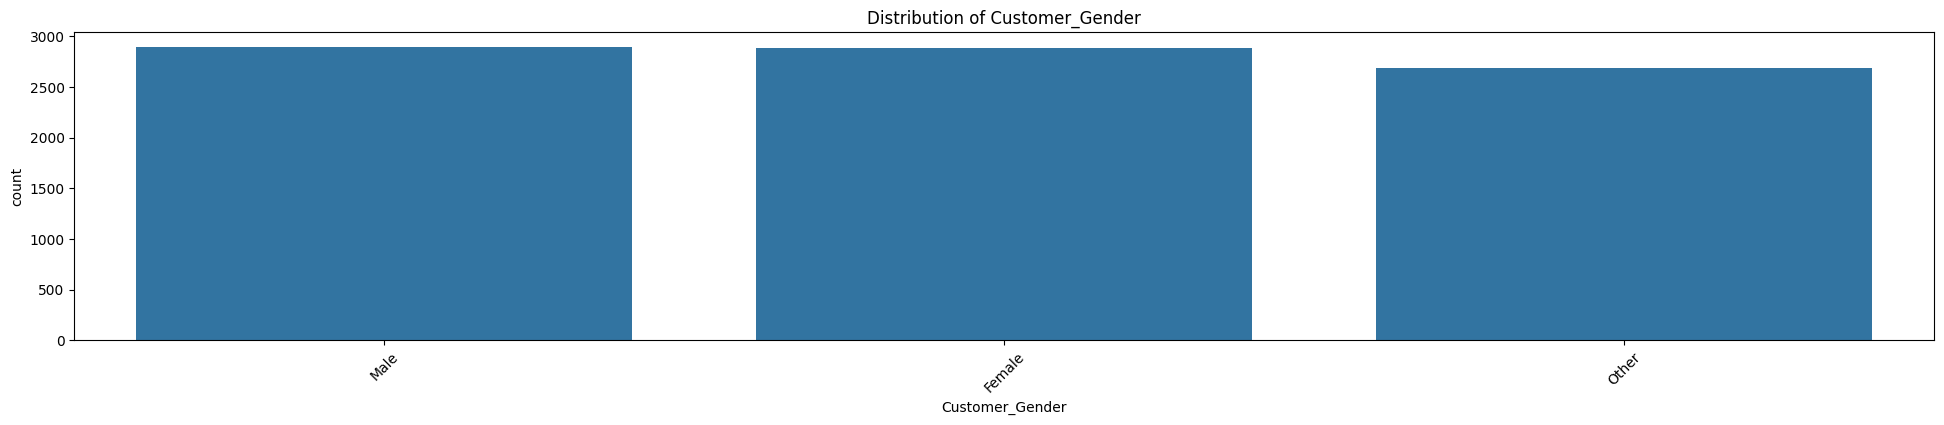

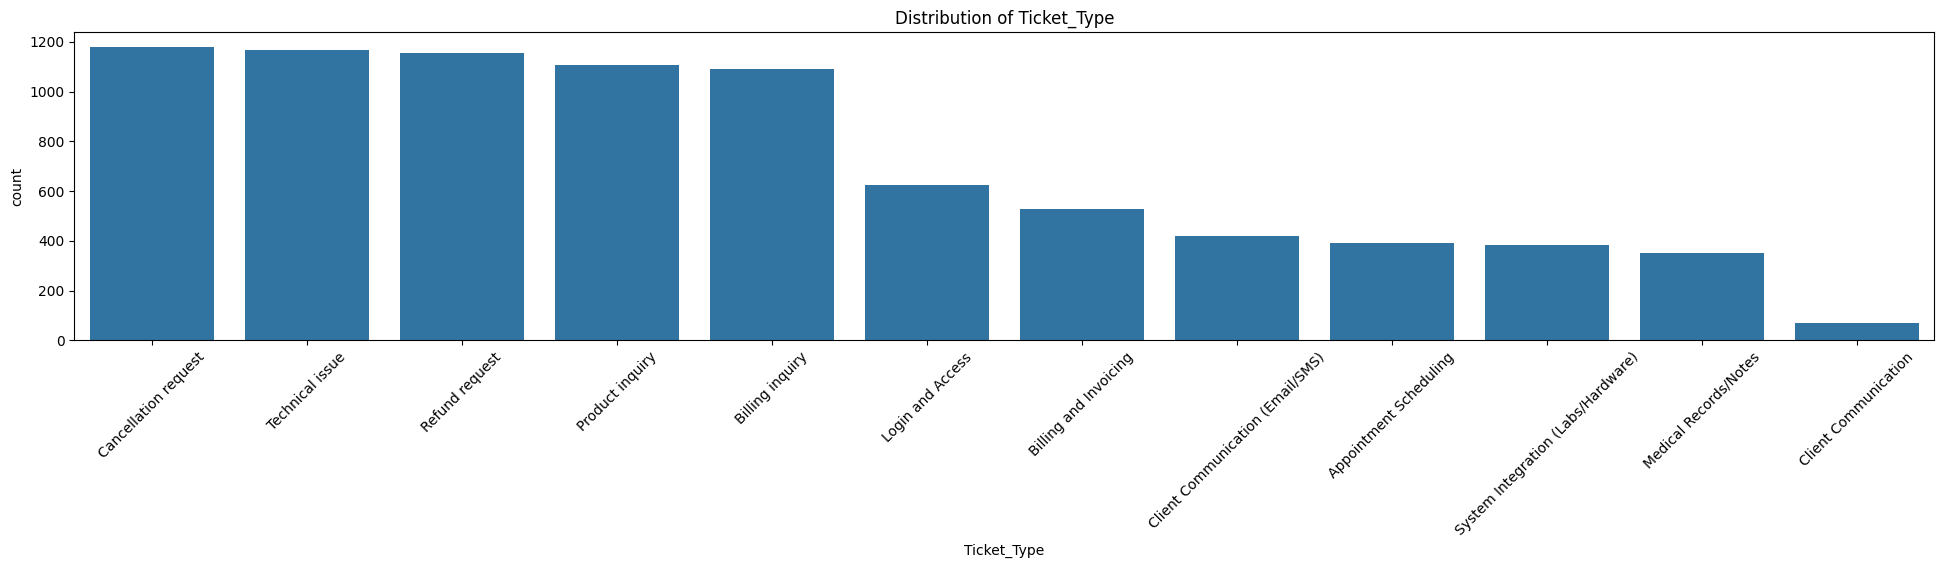

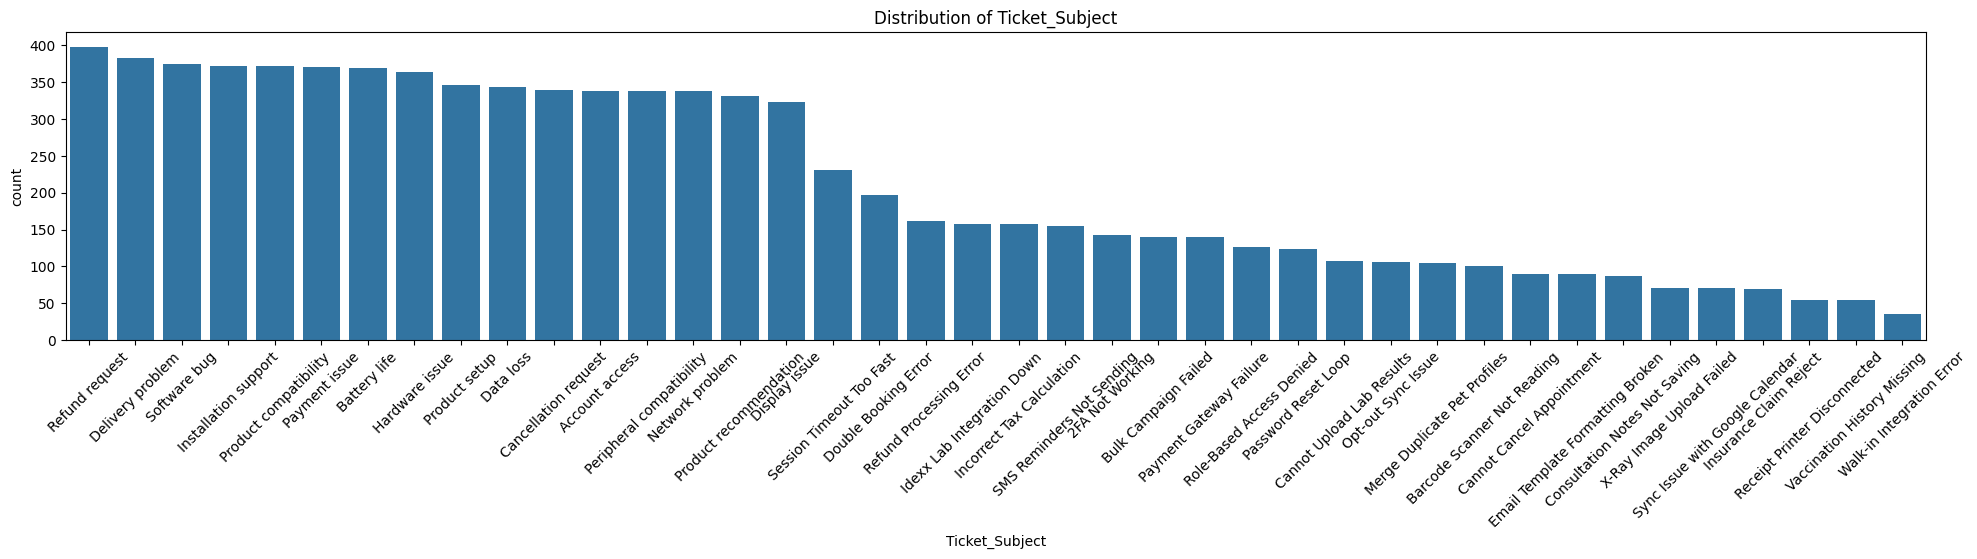

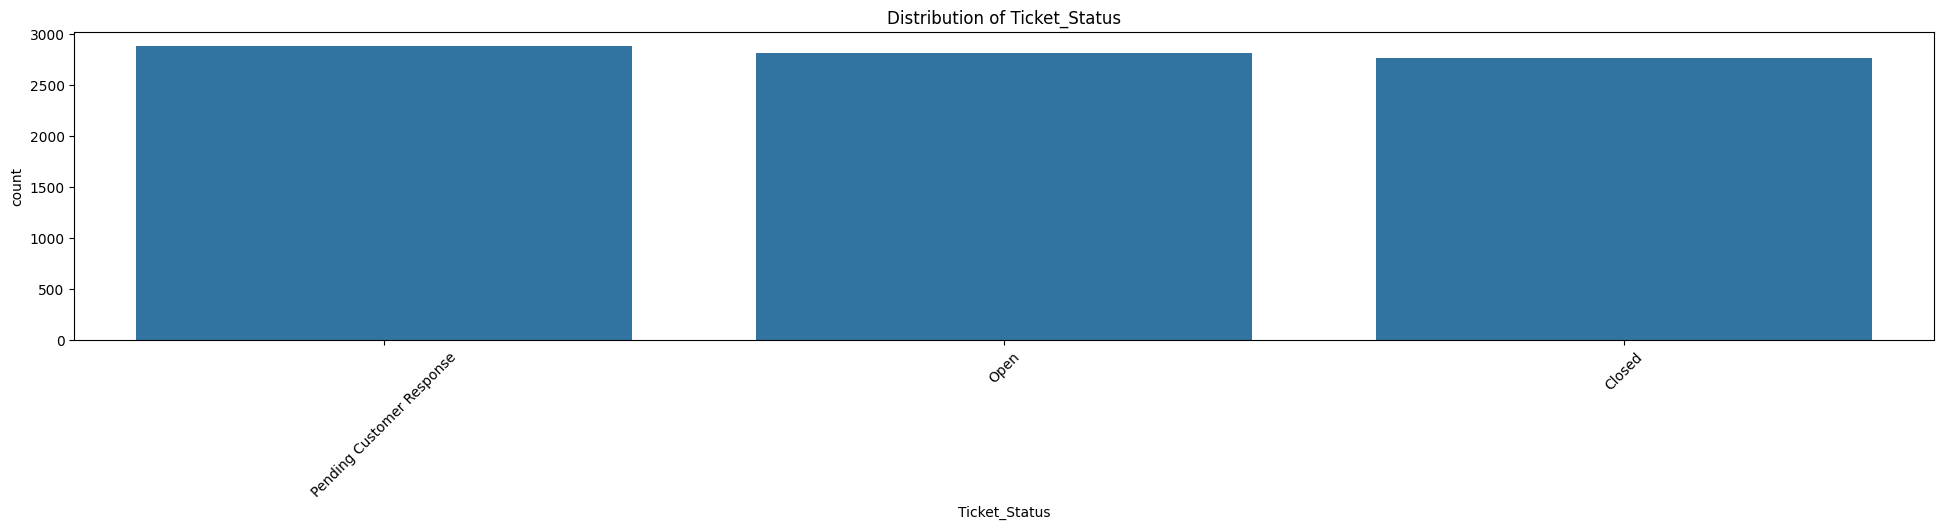

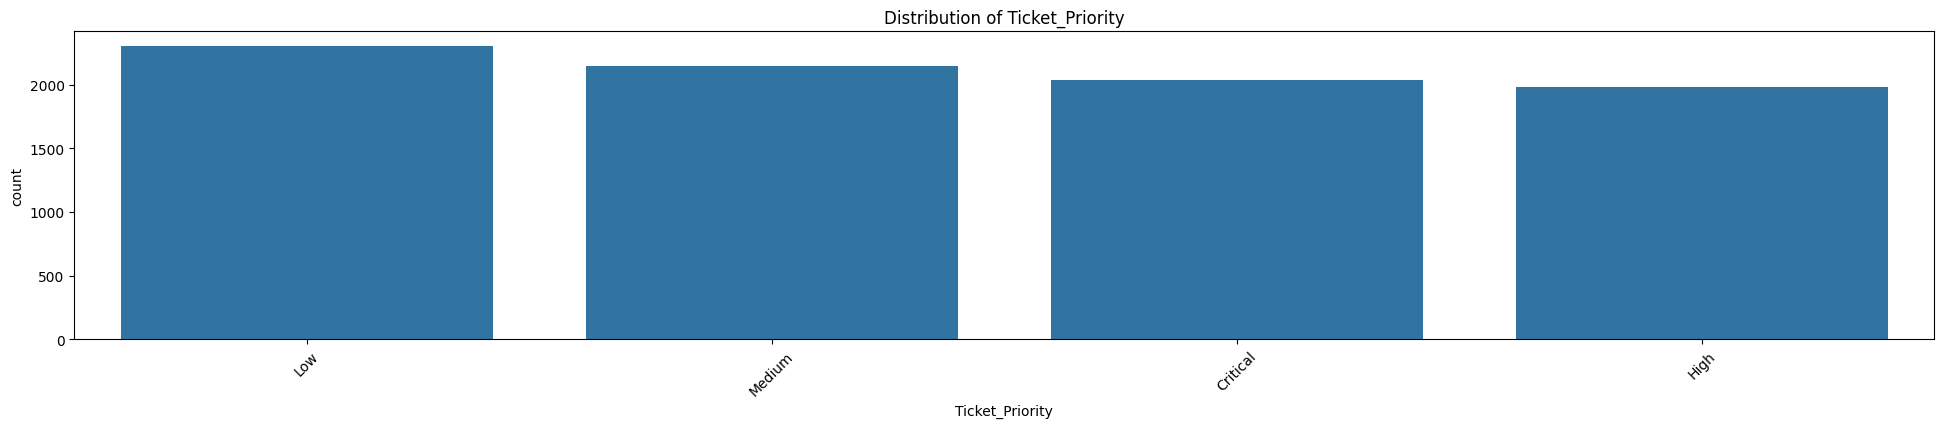

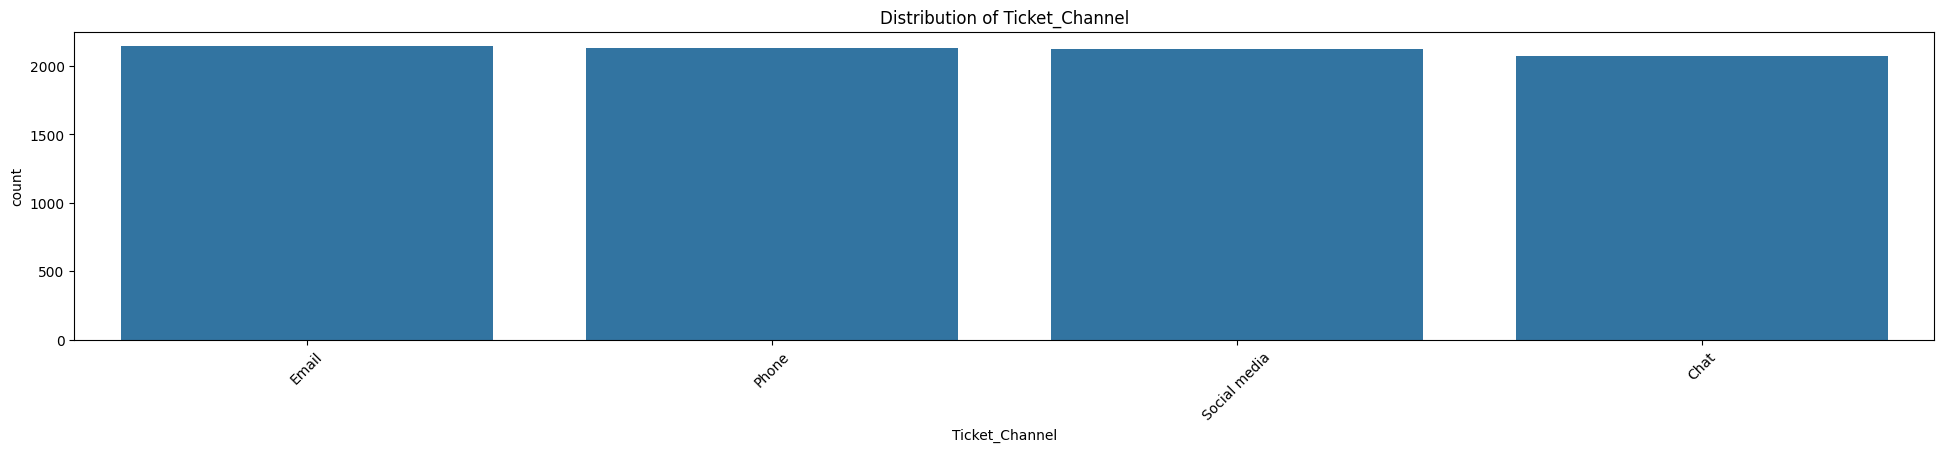

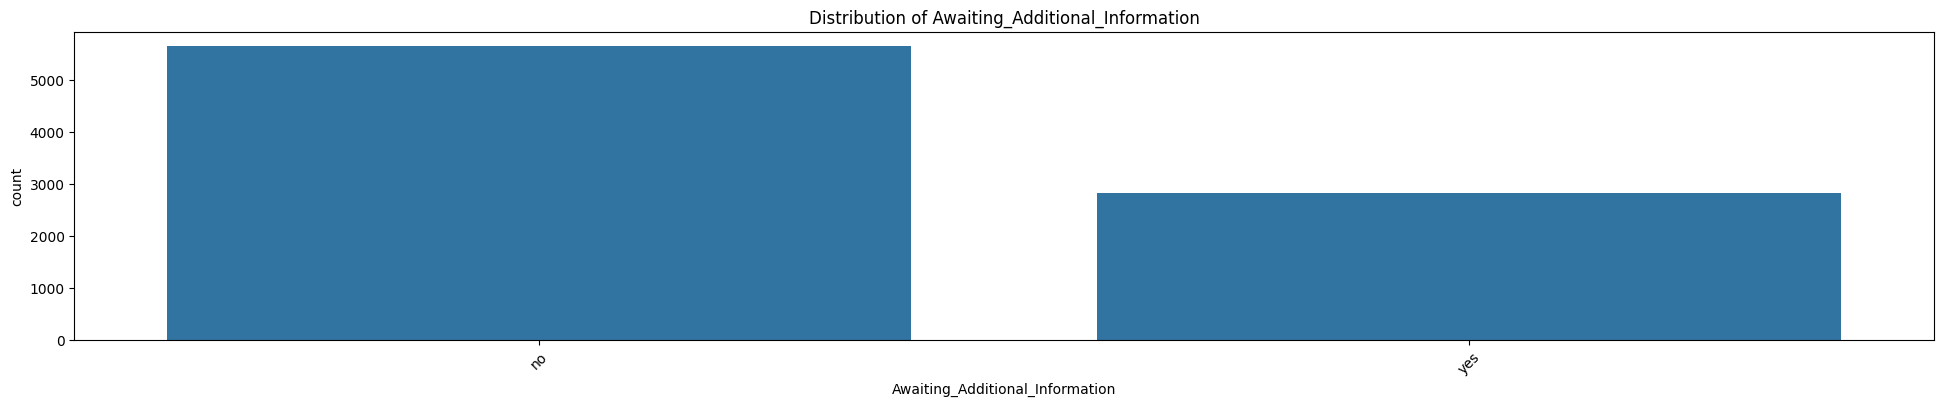

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Customer_Gender', 'Ticket_Type', 'Ticket_Subject', 'Ticket_Status', 'Ticket_Priority', 'Ticket_Channel', 
                    'Awaiting_Additional_Information']

# Plot categorical columns as bar graphs
for col in categorical_cols:
    plt.figure(figsize=(24,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


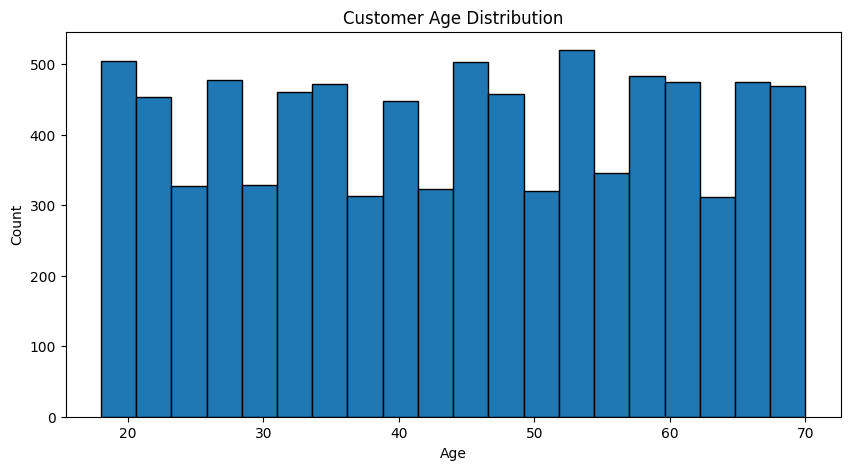

In [0]:
# Plot age histogram
plt.figure(figsize=(10,5))
plt.hist(df['Customer_Age'], bins=20, edgecolor='black')
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Text analysis

In [0]:
%pip install nltk

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/spark-994fa4f1-cdbb-4743-8bcc-a9/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


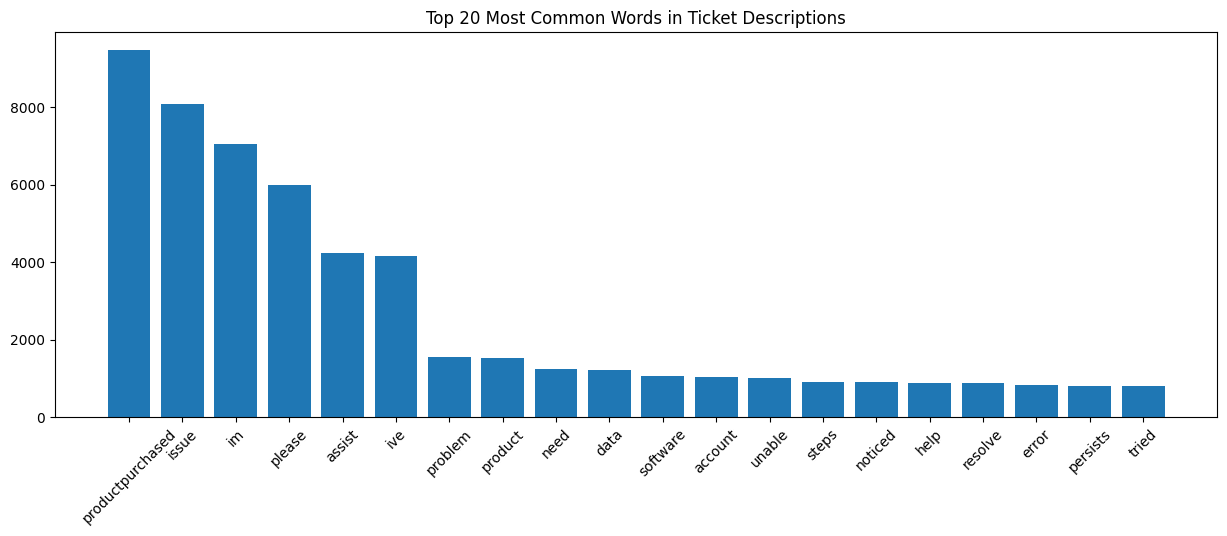

In [0]:
from collections import Counter
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Combine all issue descriptions
all_text = " ".join(df['Ticket_Description'])

# Tokenize
words = [w for w in all_text.split() if w not in stop_words]

# Most common words
word_freq = Counter(words).most_common(20)

# Plot most common words
word_df = pd.DataFrame(word_freq, columns=['word', 'count'])
plt.figure(figsize=(15,5))
plt.bar(word_df['word'], word_df['count'])
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words in Ticket Descriptions")
plt.show()

### Embedding

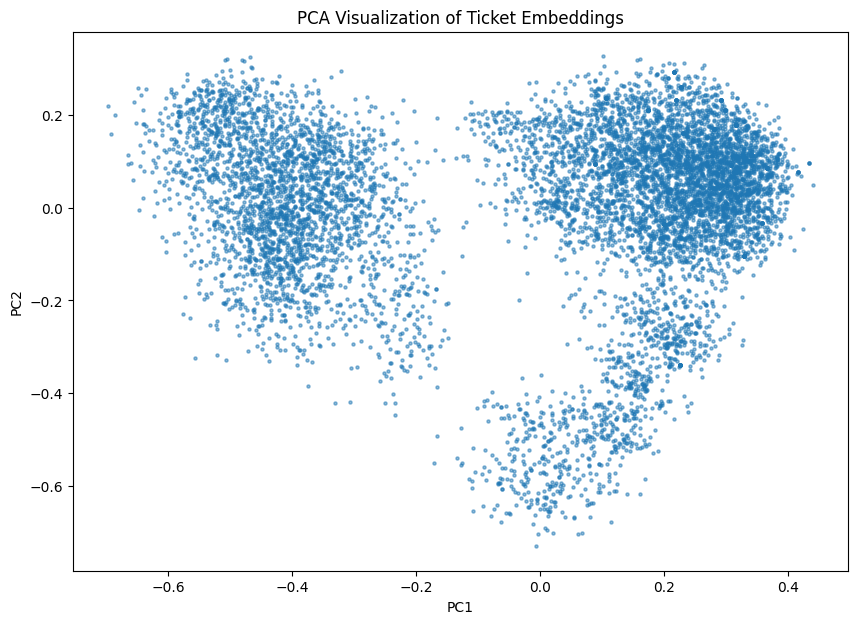

In [0]:
from sklearn.decomposition import PCA

# Convert embeddings column to array
emb_matrix = np.vstack(df['embeddings'].values)

# Reduce to 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_matrix)

# Plot
plt.figure(figsize=(10,7))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=5, alpha=0.5)
plt.title("PCA Visualization of Ticket Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


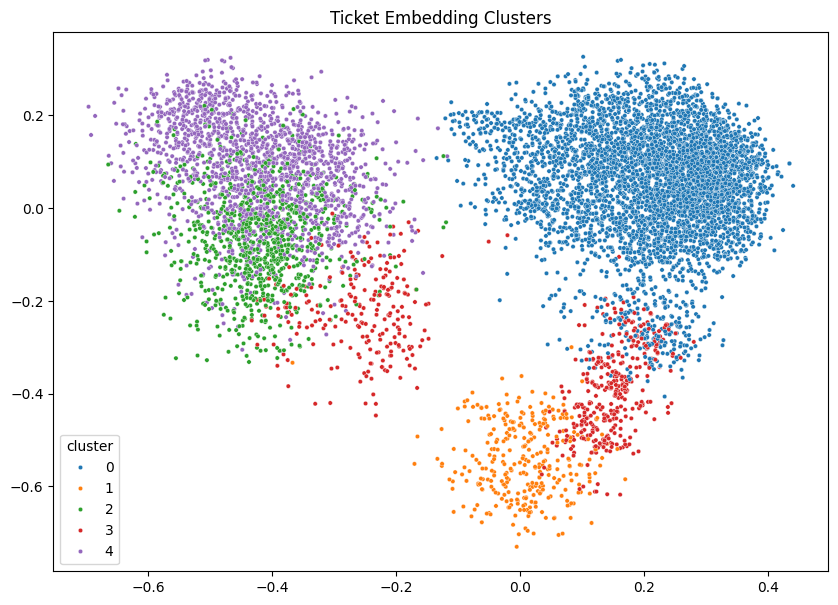


Cluster 0 top words:
[('the', 15706), ('productpurchased', 8349), ('issue', 7282), ('im', 6292), ('to', 5895), ('please', 5756), ('with', 5378), ('my', 4752), ('an', 4669), ('having', 4279), ('a', 4203), ('it', 4182), ('assist', 4172), ('and', 3455), ('ive', 3249), ('i', 3172), ('is', 3125), ('this', 2743), ('you', 2622), ('but', 2608)]

Cluster 1 top words:
[('the', 1046), ('to', 691), ('my', 621), ('productpurchased', 534), ('data', 519), ('ive', 439), ('i', 386), ('and', 376), ('is', 370), ('on', 336), ('it', 313), ('issue', 287), ('any', 268), ('a', 261), ('there', 253), ('deleted', 246), ('files', 240), ('them', 237), ('way', 234), ('recover', 232)]

Cluster 2 top words:
[('the', 956), ('to', 735), ('is', 555), ('for', 554), ('a', 431), ('this', 373), ('we', 364), ('our', 318), ('lab', 316), ('i', 300), ('not', 231), ('are', 226), ('and', 222), ('results', 198), ('need', 194), ('upload', 181), ('system', 169), ('in', 166), ('records', 160), ('idexx', 159)]

Cluster 3 top words:
[

In [0]:
from sklearn.cluster import KMeans

pca = PCA(n_components=10).fit_transform(emb_matrix)

# Cluster embeddings
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(pca)

# Visualize clusters
plt.figure(figsize=(10,7))
sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=df['cluster'], palette='tab10', s=10)
plt.title("Ticket Embedding Clusters")
plt.show()

# Gather most common words for each cluster
def top_words_for_cluster(cluster_id, n=20):
    texts = df[df['cluster'] == cluster_id]['Ticket_Description']
    all_words = " ".join(texts).split()
    common = Counter(all_words).most_common(n)
    return common

# Print top words for each cluster
for c in sorted(df['cluster'].unique()):
    print(f"\nCluster {c} top words:")
    print(top_words_for_cluster(c))

# Gather sample tickets for each cluster
def sample_tickets(cluster_id, n=5):
    return df[df['cluster'] == cluster_id]['Ticket_Description'].head(n)

# Print sample tickets for each cluster
for c in sorted(df['cluster'].unique()):
    print(f"\nCluster {c} sample tickets:")
    print(sample_tickets(c))

In [0]:
# Group clusters by priority
cluster_high_priority = (
    df.groupby('cluster')
      .apply(lambda x: (x['Ticket_Priority'].isin(['High', 'Critical'])).mean(), include_groups=False)
      .sort_values()
)
print("High Priority Rate by Cluster:")
print(cluster_high_priority)

if 'Customer Satisfaction Rating' in df.columns:
    cluster_satisfaction = (
        df.groupby('cluster')['Customer_Satisfaction_Rating']
          .mean()
          .sort_values()
    )
    print("\nMean Customer Satisfaction Rating by Cluster (1-5):")
    print(cluster_satisfaction)

High Priority Rate by Cluster:
cluster
2    0.448394
4    0.454328
3    0.460751
0    0.484232
1    0.524540
dtype: float64
